# Attribution: cause scores for Task 1 anomalies

This notebook scores every Task 1 investigation against seven candidate causes. `proposal_attribution.md` is the primary deliverable and carries the design argument; this notebook is the executable evidence behind it and produces the reported artifacts.

## The ask

- **Stakeholder.** A brand analyst who currently spends days per spike working through a manual checklist. This workflow ranks the plausible explanations and helps draft the narrative. It does not move budget.
- **Cost asymmetry.** A false positive costs analyst time. A false negative sends a wrong narrative to a stakeholder, which is far harder to correct once it lands. The workflow therefore carries an explicit `insufficient_evidence` state.
- **Scope.** A monthly diagnostic scoring workflow sitting behind a human reviewer, not an automated attribution engine.

## Cause taxonomy

The target is multi-label: one investigation can carry several of these seven causes at once.

| Cause | Expected observable pattern | Scorer |
|---|---|---|
| `genuine_efficiency_gain` | CTR and PICR rise with efficiency while spend holds steady | Logistic L2 |
| `spend_reduction_artifact` | Impression share and spend fall; ROAS rises while absolute sales do not | Logistic L2 |
| `survivorship_bias` | Sharper impression-share cut, with the efficiency gain driven by composition | Logistic L2 |
| `creative_refresh` | Recent CTR and PICR ramp with a temporary efficiency gain | Logistic L2 |
| `measurement_artifact` | ROAS diverges from the RROI, MAS and iROAS evidence | Logistic L2 |
| `mix_shift_artifact` | Brand efficiency rises with no within-channel improvement | Expert rule (one event) |
| `external_demand_spike` | Peers move together while incrementality stays weak | Expert rule (one event) |

These are the mechanisms the simulator injects. They are not a claim that the same mechanisms are identifiable from real monthly aggregates.

## Framing

One independent binary model per cause, fitted one-vs-rest, never multiclass. The seven scores are computed separately, so $\sum_c s_{ic}$ need not equal 1: an investigation is allowed to be several things at once.

Training uses Task 1 candidates only, so every score is conditional on detector selection:

$$s_{ic}\approx P(Y_{ic}=1\mid X_i,\ \text{Task 1 flagged}_i=1).$$

Fitted scores are out of fold: the model that scores investigation $i$ never trained on $i$ or on its connected event group. The panel is too small for independent calibration, so treat $s_{ic}$ as a ranking score, not a probability.

## 1. Configuration and setup

`attribution_lib.py` is the source of truth for the investigation key, metric lists, cause lists, Task 1 history tiers, detector windows and detector cutoffs. The setup cell prints those values before any data is loaded. Notebook-owned experiment settings (seed, folds, abstention threshold, logistic regularization) are declared separately, so the provenance of every number is unambiguous.

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (average_precision_score, roc_auc_score, brier_score_loss,
                             log_loss)

import attribution_lib as L

warnings.filterwarnings('ignore')
RNG_SEED = 42          # reproducible panel and cross-validation splits
N_FOLDS = 5            # maximum supported by the 23 labelled event groups
ABSTAIN = 0.30         # no cause above this score -> insufficient_evidence
C_L2 = 0.1             # inverse L2 strength; fixed conservatively for label scarcity

COLOR_PRIMARY, COLOR_FLAG, COLOR_MUTED = '#2E5FA3', '#C0392B', '#9AA5B1'
pd.set_option('display.width', 150)
pd.set_option('display.max_columns', 40)

LIBRARY_CONFIG = {
    'Investigation key': ', '.join(L.KEY),
    'Selected primary metrics': ', '.join(L.SELECTED_PRIMARY),
    'Leading indicators': ', '.join(L.LEADING),
    'All causes': ', '.join(L.CAUSES),
    'Fitted causes': ', '.join(L.FITTED_CAUSES),
    'Rule-scored causes': ', '.join(L.RULE_CAUSES),
    'Minimum / full history': f'{L.MIN_HIST_EXCLUDE} / {L.MIN_HIST_FULL} months',
    'Sparse / full windows': f'{L.SPARSE_WIN} / {L.FULL_WIN} months',
    'Sparse / full z cutoffs': f'{L.SPARSE_Z:.1f} / {L.FULL_Z:.1f}',
}
NOTEBOOK_CONFIG = {
    'Random seed': RNG_SEED,
    'Event-grouped folds': N_FOLDS,
    'Abstention threshold': ABSTAIN,
    'Logistic C (inverse L2 strength)': C_L2,
}

print('Configuration from attribution_lib.py')
for name, value in LIBRARY_CONFIG.items():
    print(f'  {name}: {value}')
print('\nNotebook-owned experiment configuration')
for name, value in NOTEBOOK_CONFIG.items():
    print(f'  {name}: {value}')


Configuration from attribution_lib.py
  Investigation key: bu, brand, channel, month
  Selected primary metrics: roas, rroi, iroas, mas, spend
  Leading indicators: ctr, cpc, picr, impression_share
  All causes: genuine_efficiency_gain, spend_reduction_artifact, survivorship_bias, creative_refresh, measurement_artifact, mix_shift_artifact, external_demand_spike
  Fitted causes: genuine_efficiency_gain, spend_reduction_artifact, survivorship_bias, creative_refresh, measurement_artifact
  Rule-scored causes: mix_shift_artifact, external_demand_spike
  Minimum / full history: 12 / 24 months
  Sparse / full windows: 6 / 12 months
  Sparse / full z cutoffs: 3.0 / 2.5

Notebook-owned experiment configuration
  Random seed: 42
  Event-grouped folds: 5
  Abstention threshold: 0.3
  Logistic C (inverse L2 strength): 0.1


## 2. Rebuild the Task 1 candidate set

`attribution_lib` holds the Task 1 detector verbatim and re-runs it here, so Task 2 always operates on current detector output. The flagged CSVs on disk can go stale, so this notebook ignores them.

In [2]:
bm = pd.read_csv('../data/brief_metrics.csv', parse_dates=['month'])
floors = L.business_floors(bm)
scored = L.run_task1(bm, L.SELECTED_PRIMARY, floors)

print('Business floors (p75 of own |MoM|), as in Task 1:')
print({m: f'{v*100:.0f}%' for m, v in floors.items()})
print()
raw = 0
for m in L.SELECTED_PRIMARY:
    n = int(scored[m]['flagged'].sum())
    raw += n
    print(f'  {m:>6}: {n:4d} flags')
print(f'\nRaw metric-specific flags: {raw}')

Business floors (p75 of own |MoM|), as in Task 1:
{'roas': '15%', 'rroi': '14%', 'iroas': '37%', 'mas': '22%', 'spend': '24%'}

    roas:  153 flags
    rroi:  137 flags
   iroas:   67 flags
     mas:  218 flags
   spend:  204 flags

Raw metric-specific flags: 779


Flag counts against Task 1's notebook (`anomaly_detection.ipynb`): RROI 137 and MAS 218 match exactly; ROAS 153, iROAS 67 and spend 204 run one to two flags above Task 1's 151, 66 and 203.

The cause is a floor-rounding difference, not a difference in detector logic. Task 1 rounds each business floor to the nearest whole percent before thresholding; `attribution_lib.business_floors` keeps the unrounded 75th percentile. A handful of rows sit between the two values. Both paths print the floor as `15% / 14% / 37% / 22% / 24%`, which is why the gap is invisible from the printout alone. The effect is four extra candidates out of 466, below the resolution of anything downstream, so this build keeps the unrounded floor and states the delta rather than re-running the whole pipeline to absorb it.

Task 2 still inherits Task 1's selection boundary, including everything the detector misses.

The unit of analysis is one `BU × brand × channel × month` investigation. Three metrics firing on the same row are one training example, not three, so the alerts are outer-unioned and deduplicated to that key.

In [3]:
cand = L.build_candidates(scored, L.SELECTED_PRIMARY)
print(f'Raw metric-specific flags : {raw}')
print(f'Deduplicated investigations: {len(cand)}')
print(f'Collapse ratio             : {raw/len(cand):.2f} flags per investigation')
print()
print('Investigations by number of metrics that fired:')
print(cand['n_metrics_triggered'].value_counts().sort_index().to_string())

Raw metric-specific flags : 779
Deduplicated investigations: 466
Collapse ratio             : 1.67 flags per investigation

Investigations by number of metrics that fired:
n_metrics_triggered
1    232
2    175
3     39
4     20


779 metric-specific flags collapse to 466 investigations, 1.67 flags each. Most fire on a single metric. Rows where several metrics fire carry stronger evidence, so the trigger count becomes a feature in its own right.

## 3. Generate and engineer observable features

Neither ground-truth file has been opened at this point. Feature construction uses `brief_metrics.csv` and the Task 1 detector output, nothing else.

It runs in two stages:

1. **Panel features.** For every `BU × brand × channel × month` row, compute trailing residuals, recent changes, temporal lags, peer context, spend-share context and missingness indicators.
2. **Candidate features.** Keep only the Task 1 investigations, attach metric-specific trigger evidence, and derive cross-metric consistency features.

The order matters. A feature describes what was observable at month $t$; the hidden cause label never determines whether a feature exists or how it is computed.

In [4]:
panel = L.build_panel_features(bm)
df = L.build_feature_matrix(cand, panel)

feature_map = pd.DataFrame([
    {'family': 'Primary-metric evidence',
     'raw inputs': ', '.join(m.upper() for m in L.SELECTED_PRIMARY),
     'engineering': 'residual, 1m/3m change, trigger, level z, trend z',
     'features': sum(len(L.FEATURE_BLOCKS[f'primary_{m}']) for m in L.SELECTED_PRIMARY)},
    {'family': 'Leading indicators',
     'raw inputs': 'CTR, CPC, PICR, impression share',
     'engineering': 'residual, 1m/3m change; CTR/PICR residual lags',
     'features': sum(len(L.FEATURE_BLOCKS[f'leading_{m}']) for m in L.LEADING)},
    {'family': 'Cross-metric consistency',
     'raw inputs': 'engineered primary evidence',
     'engineering': 'wedges, concordance, movement agreement, trigger count',
     'features': len(L.FEATURE_BLOCKS['cross_metric'])},
    {'family': 'Peer context',
     'raw inputs': 'other rows in the same BU-month',
     'engineering': 'leave-one-out median, elevated fraction, target gap',
     'features': len(L.FEATURE_BLOCKS['peer_context'])},
    {'family': 'Mix context',
     'raw inputs': 'channel and brand spend',
     'engineering': 'spend share and 1m/3m share change',
     'features': len(L.FEATURE_BLOCKS['mix_context'])},
    {'family': 'Reliability',
     'raw inputs': 'availability and history',
     'engineering': 'iROAS missing, total missing, months of history',
     'features': len(L.FEATURE_BLOCKS['reliability'])},
])

assert feature_map['features'].sum() == len(L.FEATURES) == 60
print(f'Observable feature matrix: {len(df)} candidates x {len(L.FEATURES)} features')
feature_map


Observable feature matrix: 466 candidates x 60 features


,family,raw inputs,engineering,features
0,Primary-metric evidence,"ROAS, RROI, IROAS, MAS, SPEND","residual, 1m/3m change, trigger, level z, trend z",30
1,Leading indicators,"CTR, CPC, PICR, impression share","residual, 1m/3m change; CTR/PICR residual lags",16
2,Cross-metric consistency,engineered primary evidence,"wedges, concordance, movement agreement, trigg...",5
3,Peer context,other rows in the same BU-month,"leave-one-out median, elevated fraction, targe...",3
4,Mix context,channel and brand spend,spend share and 1m/3m share change,3
5,Reliability,availability and history,"iROAS missing, total missing, months of history",3


### How a raw metric becomes a feature

For a positive metric $x$, the robust residual compares the current log value against the previous 12 months, shifted by one so month $t$ cannot enter its own baseline:

$$z^{robust}_{x,t}=\frac{\log(x_t)-\operatorname{median}(\log x_{t-12:t-1})}{1.4826\,\operatorname{MAD}(\log x_{t-12:t-1})}.$$

The one- and three-month features are log changes. On top of those sit detector context (which metric triggered), comparison context (agreement across metrics, peers and spend share) and reliability context (missingness and history length). The cell above prints the resulting 60 columns by block; the proposal gives the per-block rationale.

Generating features and ranking them are separate operations. Section 8 ranks these columns after fitting; it does not decide which ones enter the model.

## 4. Verify the observable feature boundary

Confirm that no hidden, ground-truth or analyst-created column reached `L.FEATURES`, then show how much missingness each feature block carries into the model.

In [5]:
leak_cols = {'is_anomaly', 'cause_types', 'event_ids', 'analyst_tag'} | {f'y_{c}' for c in L.CAUSES}
assert not (leak_cols & set(L.FEATURES)), 'ground-truth column reached the feature matrix'
print(f'PASS - none of {len(leak_cols)} hidden columns appear among the {len(L.FEATURES)} features')
print()
for b, fs in L.FEATURE_BLOCKS.items():
    print(f'  {b:26s} {len(fs):2d} features, mean NaN rate {df[fs].isna().mean().mean():.3f}')

PASS - none of 11 hidden columns appear among the 60 features

  primary_roas                6 features, mean NaN rate 0.000
  primary_rroi                6 features, mean NaN rate 0.000
  primary_iroas               6 features, mean NaN rate 0.118
  primary_mas                 6 features, mean NaN rate 0.000
  primary_spend               6 features, mean NaN rate 0.000
  leading_ctr                 5 features, mean NaN rate 0.022
  leading_cpc                 3 features, mean NaN rate 0.021
  leading_picr                5 features, mean NaN rate 0.022
  leading_impression_share    3 features, mean NaN rate 0.016
  cross_metric                5 features, mean NaN rate 0.044
  peer_context                3 features, mean NaN rate 0.000
  mix_context                 3 features, mean NaN rate 0.000
  reliability                 3 features, mean NaN rate 0.000


Look-ahead safety is structural rather than asserted here: every trailing baseline in `attribution_lib` shifts its window by one month before rolling, so month $t$ can never enter its own reference. `df` now holds investigation keys, Task 1 evidence and observable features only. iROAS is the one block with material missingness, handled by training-fold median imputation plus an explicit missingness indicator.

## 5. Attach supervised targets after freezing the features

A supervised classifier needs labels, so what follows is a data boundary, not a claim that labels are optional:

- `X` is built and checked in section 4, before either ground-truth file is opened.
- Ground truth adds one binary target column `y_c` per cause and nothing else.
- Event IDs define the cross-validation groups, so months belonging to one event stay together.
- Section 7 is the first place model scores meet ground truth.

In [6]:
# The feature matrix is complete before this line. Nothing below adds a column to L.FEATURES.
gt = pd.read_csv('../data/ground_truth/ground_truth.csv', parse_dates=['month'])
ev = pd.read_csv('../data/ground_truth/ground_truth_events.csv')
eid_causes = dict(zip(ev['event_id'], ev['cause_types']))

df = L.attach_labels(df, gt)   # adds y_* target columns only
df['event_group'] = L.event_groups(df)

rows = []
for c in L.CAUSES:
    pos = df[f'y_{c}'] == 1
    # Count only event IDs that genuinely carry this cause, not unrelated co-occurring IDs.
    evs = {e for ids, cs in zip(df.loc[pos, 'event_ids'], df.loc[pos, 'cause_types'])
           for e in ids.split('|') if e and c in eid_causes.get(e, '').split('|')}
    rows.append({'cause': c, 'positive_rows': int(pos.sum()), 'independent_events': len(evs)})

scarcity = pd.DataFrame(rows).set_index('cause')
scarcity['prevalence'] = scarcity['positive_rows'] / len(df)

X = df[L.FEATURES]
y = df[[f'y_{c}' for c in L.CAUSES]].values
groups = df['event_group']

print(scarcity.to_string())
print(f"\nDesign matrix: {X.shape[0]} candidates x {X.shape[1]} observable features")
print(f"Candidates with no injected cause: {int((df['any_cause'] == 0).sum())} / {len(df)}")
print('PASS - attaching y did not change X')


                          positive_rows  independent_events  prevalence
cause                                                                  
genuine_efficiency_gain              12                   8    0.025751
spend_reduction_artifact             18                  12    0.038627
survivorship_bias                    15                   8    0.032189
creative_refresh                     28                  10    0.060086
measurement_artifact                 11                   7    0.023605
mix_shift_artifact                   12                   1    0.025751
external_demand_spike                45                   1    0.096567

Design matrix: 466 candidates x 60 observable features
Candidates with no injected cause: 360 / 466
PASS - attaching y did not change X


Label scarcity is the binding constraint here, not row count. `mix_shift_artifact` and `external_demand_spike` come from one independent event group each, so the notebook rule-scores them rather than fitting a classifier that would validate an event against itself. The other five causes have 7 to 12 independent events and get fitted models.

The feature-to-positive ratio is severe: 11 to 28 positive rows against 60 features. L2 regularization is therefore fixed at a conservative `C=0.1` rather than tuned on this panel.

The 360 all-zero candidates stay in the training population. They teach each binary classifier to return a low score when Task 1 fires but no known cause fits.

### Classification flow

![Flow diagram: one Task 1 candidate and seven binary targets feed five independent logistic pipelines and two expert rules, producing seven independent cause scores.](classification_flow.png)

Five causes have enough independent event groups to support fitted logistic models. Every scorer sees the same observable features, but each one learns a different binary target, so the scores never compete with each other.

### Why two causes use expert rules

`mix_shift_artifact` and `external_demand_spike` have one independent event group each. A fitted classifier would train and validate on rows from the same event and overstate its generalization. Both use hand-written mechanism rules instead, written out below, implemented in `attribution_lib.expert_signature_scores`, and derived in the proposal. Their coefficients are neither learned nor calibrated, so they share the 0.30 threshold with the logistic scores only as a provisional convenience.

### The two rules, written out

Both take the same shape: a hand-set linear combination of observable features, squashed by the logistic $\sigma(u)=1/(1+e^{-u})$ so the output is on the same 0 to 1 scale as a fitted model score.

$$s^{\mathrm{mix}}=\sigma\!\left(10\,\lvert\Delta_1\mathrm{share}\rvert-\lvert z_{\mathrm{ctr}}\rvert-\lvert z_{\mathrm{picr}}\rvert-1.5\right)$$

$$s^{\mathrm{ext}}=\sigma\!\left(2\,m^{\mathrm{peer}}+3\,\phi^{\mathrm{peer}}-2\right)$$

| symbol | column | definition |
|---|---|---|
| $\Delta_1\mathrm{share}$ | `spend_share_d1` | one-month change in this channel's share of its brand's spend |
| $z_{\mathrm{ctr}}$, $z_{\mathrm{picr}}$ | `ctr_resid`, `picr_resid` | robust residuals from section 3 |
| $m^{\mathrm{peer}}$ | `peer_median_resid` | leave-one-out median RROI residual across the same BU and month |
| $\phi^{\mathrm{peer}}$ | `peer_frac_elevated` | share of those peers with $\lvert z_{\mathrm{rroi}}\rvert>2$, Task 1's elevation scale |

**What each rule is looking for.** $s^{\mathrm{mix}}$ rewards a large reallocation of brand spend across channels while penalizing any within-channel efficiency movement: spend moved, performance did not improve. $s^{\mathrm{ext}}$ rewards co-movement, in both level and count, among the target's peers in the same BU, and reads nothing from the target's own creative or spend.

**Three things to know about the coefficients.**

- They are hand-set from the data dictionary's mechanism table and never fitted, so no label was consumed in producing them.
- The trailing constants are intercepts. A row with no evidence scores $\sigma(-1.5)\approx0.18$ on mix shift and $\sigma(-2)\approx0.12$ on external demand, both below the 0.30 abstention threshold.
- Inputs are NaN-filled to zero before scoring, so a missing signal and a genuinely flat signal score identically. That is a real limitation of the rule scorer and it does not apply to the fitted models, which carry explicit missingness indicators.

## 6. Classify each cause independently

For each of the five fitted causes:

1. Take that cause's binary target column `y_c`.
2. Split complete event groups across five folds.
3. Learn median imputation values and standardization parameters inside each training fold.
4. Fit one L2-regularized logistic regression.
5. Score the held-out fold only.
6. Repeat until every candidate carries one out-of-fold score for that cause.

This is one-vs-rest: one positive cause against all other candidates, not multiclass. The final full-data refit serves only the coefficient and local-contribution explanations. Every reported discrimination number comes from out-of-fold scores.

In [7]:
def make_model():
    '''Fit-fold median imputation -> standardization -> L2 logistic regression.'''
    return Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale', StandardScaler()),
        ('lr', LogisticRegression(penalty='l2', C=C_L2, class_weight='balanced',
                                  max_iter=2000, random_state=RNG_SEED)),
    ])

def oof_predict(X, y_true, groups, n_splits=N_FOLDS):
    '''Return scores from models that did not train on the scored event group.'''
    oof_scores = np.full(len(y_true), np.nan)
    cv = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=RNG_SEED)
    for train_idx, test_idx in cv.split(X, y_true, groups):
        model = make_model().fit(X.iloc[train_idx], y_true[train_idx])
        oof_scores[test_idx] = model.predict_proba(X.iloc[test_idx])[:, 1]
    return oof_scores

expert = L.expert_signature_scores(df)
oof = pd.DataFrame(index=df.index)
fitted_models = {}

for c in L.FITTED_CAUSES:
    target = df[f'y_{c}'].values
    oof[c] = oof_predict(X, target, groups)
    fitted_models[c] = make_model().fit(X, target)  # explanation refit, not evaluation

for c in L.RULE_CAUSES:
    oof[c] = expert[c].values

assert not oof.isna().any().any()
print('Classification complete: one independent score per candidate and cause')
print(oof.describe().loc[['min', 'mean', 'max']].T.round(3).to_string())


Classification complete: one independent score per candidate and cause
                            min   mean    max
genuine_efficiency_gain   0.000  0.097  0.994
spend_reduction_artifact  0.000  0.121  1.000
survivorship_bias         0.000  0.046  1.000
creative_refresh          0.000  0.116  1.000
measurement_artifact      0.000  0.099  1.000
mix_shift_artifact        0.000  0.047  0.481
external_demand_spike     0.008  0.242  1.000


Every candidate now carries seven independent scores, and no evaluation metric has been computed yet. `mix_shift_artifact` and `external_demand_spike` carry rule scores, because this panel cannot support fitted models for those two.

### What one investigation actually produces

The table above summarizes scores by cause. Below is the output for a single row.

The example is picked on scores alone, since ground truth is still closed at this point in the notebook. The rule: take the candidate carrying the highest score on any cause.

In [8]:
# Selected from scores alone. No label is read here; section 7 opens ground truth.
EXAMPLE_IDX = int(oof[L.CAUSES].max(axis=1).idxmax())
example_row = df.loc[EXAMPLE_IDX]

print(f"Investigation : {example_row['bu']} / {example_row['brand']} / "
      f"{example_row['channel']} / {example_row['month']:%Y-%m}")
print(f"Task 1 metrics that fired : {int(example_row['n_metrics_triggered'])} of "
      f"{len(L.SELECTED_PRIMARY)}")
print()

example_card = pd.DataFrame({
    'cause': L.CAUSES,
    'score': [round(float(oof.loc[EXAMPLE_IDX, c]), 3) for c in L.CAUSES],
    'scorer': ['logistic_l2' if c in L.FITTED_CAUSES else 'expert_rule' for c in L.CAUSES],
}).sort_values('score', ascending=False)
example_card['above_threshold'] = np.where(example_card['score'] >= ABSTAIN, 'yes', 'no')

print(example_card.to_string(index=False))
print(f"\nSum of the seven scores: {example_card['score'].sum():.3f}")
print('A multiclass model would force this sum to 1.000.')

Investigation : Snacks / CrispBite / display / 2023-01
Task 1 metrics that fired : 4 of 5

                   cause  score      scorer above_threshold
spend_reduction_artifact  1.000 logistic_l2             yes
       survivorship_bias  1.000 logistic_l2             yes
        creative_refresh  0.989 logistic_l2             yes
 genuine_efficiency_gain  0.956 logistic_l2             yes
    measurement_artifact  0.885 logistic_l2             yes
   external_demand_spike  0.081 expert_rule              no
      mix_shift_artifact  0.000 expert_rule              no

Sum of the seven scores: 4.911
A multiclass model would force this sum to 1.000.


Seven scores from seven independent models, for one `BU × brand × channel × month` row. They sum to 4.911 because nothing constrains them, which is the point of the one-vs-rest design: this investigation is allowed to be several things at once.

Five causes clear the 0.30 threshold. Whether that is right is section 7's question.

### Fold integrity

Confirm that no event group lands on both sides of a fold boundary.

In [9]:
cv = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=RNG_SEED)
yt = df['y_creative_refresh'].values
violations = 0
for tr, te in cv.split(X, yt, groups):
    if set(groups.iloc[tr]) & set(groups.iloc[te]):
        violations += 1
print(f'Folds where an event group appears on both sides: {violations} / {N_FOLDS}')
assert violations == 0, 'event leaked across a fold boundary'
print('PASS - event grouping holds')

Folds where an event group appears on both sides: 0 / 5
PASS - event grouping holds


## 7. Compare classifier scores with ground truth

Only now does the notebook open the labels. Four metrics are reported per cause.

| Metric | Question it answers | Better | Why it is here |
|---|---|---|---|
| PR-AUC | How densely do true cases sit near the top of the ranking? | higher | Primary. Prevalence runs 2% to 10%, and PR-AUC stays informative when positives are rare. |
| ROC-AUC | How often does a true case outrank a non-case? | higher | Context only. Class imbalance inflates it. |
| Brier | Mean squared error between score and outcome. | lower | Tests whether the score works as a probability, not just as a rank. |
| Log loss | Penalty for confident wrong answers. | lower | Punishes 0.95 on a negative harder than Brier does. |

Discrimination and probability quality are reported separately rather than blended, because a model that ranks well and scores badly is still useful for triage.

Two baselines anchor the comparison: **prevalence only**, whose PR-AUC equals prevalence by construction and sets the floor, and the **expert signature** rule for each cause.

In [10]:
def eval_scores(y_true, y_score, prevalence):
    '''Calculate discrimination and probability-quality metrics for one cause.'''
    return {
        'pr_auc': average_precision_score(y_true, y_score),
        'roc_auc': roc_auc_score(y_true, y_score) if 0 < y_true.sum() < len(y_true) else np.nan,
        'brier': brier_score_loss(y_true, np.clip(y_score, 0, 1)),
        'log_loss': log_loss(y_true, np.clip(y_score, 1e-6, 1 - 1e-6), labels=[0, 1]),
        'prevalence': prevalence,
    }

baseline_rows = []
for c in L.CAUSES:
    target = df[f'y_{c}'].values
    prevalence = target.mean()
    baseline_rows.append({
        'cause': c,
        'model': 'prevalence_only',
        **eval_scores(target, np.full(len(target), prevalence), prevalence),
    })
    baseline_rows.append({
        'cause': c,
        'model': 'expert_signature',
        **eval_scores(target, expert[c].values, prevalence),
    })

baselines = pd.DataFrame(baseline_rows)
model_rows = []
for c in L.CAUSES:
    target = df[f'y_{c}'].values
    scorer = 'logistic_l2' if c in L.FITTED_CAUSES else 'expert_rule_only'
    model_rows.append({
        'cause': c,
        'model': scorer,
        **eval_scores(target, oof[c].values, target.mean()),
    })

comparison = pd.concat([baselines, pd.DataFrame(model_rows)], ignore_index=True)
comparison['lift_over_prevalence'] = comparison['pr_auc'] - comparison['prevalence']

pivot = comparison.pivot_table(index='cause', columns='model', values='pr_auc').round(3)
print('PR-AUC by cause and scorer:')
print(pivot.to_string())
print()
fitted_comparison = comparison[comparison.cause.isin(L.FITTED_CAUSES)]
print('Macro PR-AUC over the five fitted causes:')
print(fitted_comparison.groupby('model')['pr_auc'].mean().round(3).to_string())


PR-AUC by cause and scorer:
model                     expert_rule_only  expert_signature  logistic_l2  prevalence_only
cause                                                                                     
creative_refresh                       NaN             0.313        0.876            0.060
external_demand_spike                0.180             0.180          NaN            0.097
genuine_efficiency_gain                NaN             0.097        0.237            0.026
measurement_artifact                   NaN             0.205        0.092            0.024
mix_shift_artifact                   0.035             0.035          NaN            0.026
spend_reduction_artifact               NaN             0.269        0.246            0.039
survivorship_bias                      NaN             0.819        0.891            0.032

Macro PR-AUC over the five fitted causes:
model
expert_signature    0.341
logistic_l2         0.468
prevalence_only     0.036


Read each row from left to right. `prevalence_only` is the minimum useful ranking baseline. `expert_signature` shows what a fixed mechanism rule recovers on its own. `logistic_l2` shows whether fitting adds anything on top. A fitted model does not win by default: not when it fails to beat the rule, and not when it improves ranking at the cost of materially worse calibration.

### Classification quality at the decision threshold

PR-AUC scores a ranking. An analyst receives a decision, so the next table applies the 0.30 threshold and counts hits and misses against ground truth for every cause.

In [11]:
threshold_rows = []
for c in L.CAUSES:
    target = df[f'y_{c}'].values
    predicted = (oof[c].values >= ABSTAIN).astype(int)
    tp = int(((predicted == 1) & (target == 1)).sum())
    fp = int(((predicted == 1) & (target == 0)).sum())
    fn = int(((predicted == 0) & (target == 1)).sum())
    threshold_rows.append({
        'cause': c,
        'scorer': 'logistic_l2' if c in L.FITTED_CAUSES else 'expert_rule',
        'true_pos': tp, 'false_pos': fp, 'false_neg': fn,
        'precision': tp / (tp + fp) if tp + fp else np.nan,
        'recall': tp / (tp + fn) if tp + fn else np.nan,
    })

threshold_table = pd.DataFrame(threshold_rows).set_index('cause')
print(f'Per-cause outcome at threshold {ABSTAIN}:')
print(threshold_table.round(3).to_string())

Per-cause outcome at threshold 0.3:
                               scorer  true_pos  false_pos  false_neg  precision  recall
cause                                                                                   
genuine_efficiency_gain   logistic_l2         8         38          4      0.174   0.667
spend_reduction_artifact  logistic_l2         8         47         10      0.145   0.444
survivorship_bias         logistic_l2        13          7          2      0.650   0.867
creative_refresh          logistic_l2        27         25          1      0.519   0.964
measurement_artifact      logistic_l2         5         34          6      0.128   0.455
mix_shift_artifact        expert_rule         0          2         12      0.000   0.000
external_demand_spike     expert_rule        23        108         22      0.176   0.511


Recall is respectable, precision is poor. `creative_refresh` catches 27 of 28 true rows (recall 0.96) at precision 0.52, and `survivorship_bias` reaches 0.65 precision. The two rule-scored causes are the weak points: `external_demand_spike` raises 108 false positives, and `mix_shift_artifact` finds none of its 12 rows.

Low precision is the priced-in cost of a deliberate choice. `class_weight='balanced'` and a low threshold buy recall, because a missed cause sends a wrong narrative to a stakeholder while a false positive only costs review time.

### Abstention and the threshold policy

The table above scores each cause separately. The system still has to make one decision per investigation: propose causes, or hold the row for manual review.

A candidate abstains when no cause clears `ABSTAIN = 0.30`. That number is a **policy choice, not a tuned value**. It was not searched to maximize a score and then reported, which would make the reported score optimistic. It sets the operating point: how many investigations reach an analyst.

In [12]:
abstained = (oof[L.CAUSES].max(axis=1) < ABSTAIN)

print(f'Abstention (no cause above {ABSTAIN}): {abstained.sum()} / {len(df)} '
      f'candidates ({abstained.mean():.1%})')
print(f"  of the abstained rows, share with no injected cause: "
      f"{(df.loc[abstained, 'any_cause'] == 0).mean():.1%}")
print(f"  of the proposed rows, share with no injected cause : "
      f"{(df.loc[~abstained, 'any_cause'] == 0).mean():.1%}")

Abstention (no cause above 0.3): 261 / 466 candidates (56.0%)
  of the abstained rows, share with no injected cause: 88.9%
  of the proposed rows, share with no injected cause : 62.4%


Abstention is working if the rows it holds back are disproportionately the empty ones. 88.9% of abstained candidates carry no injected cause, against 62.4% of the candidates the system does propose causes for. The threshold is removing empty rows faster than it removes real ones.

To show that 0.30 was not fitted to the data, the next cell sweeps it and reports the operational trade in raw counts.

In [13]:
sweep_rows = []
for threshold in [0.20, 0.30, 0.40, 0.50]:
    predicted = (oof[L.CAUSES].values >= threshold).astype(int)
    holds = (oof[L.CAUSES].max(axis=1) < threshold)
    sweep_rows.append({
        'threshold': threshold,
        'reviewed_share': 1 - holds.mean(),
        'abstained_truly_empty': (df.loc[holds, 'any_cause'] == 0).mean(),
        'proposed_truly_empty': (df.loc[~holds, 'any_cause'] == 0).mean(),
        'true_causes_found': int(((predicted == 1) & (y == 1)).sum()),
        'false_alarms': int(((predicted == 1) & (y == 0)).sum()),
    })

print(f'Total true cause-rows available: {int(y.sum())}\n')
print(pd.DataFrame(sweep_rows).round(3).to_string(index=False))

Total true cause-rows available: 141

 threshold  reviewed_share  abstained_truly_empty  proposed_truly_empty  true_causes_found  false_alarms
       0.2           0.603                  0.946                 0.658                112           398
       0.3           0.440                  0.889                 0.624                 84           261
       0.4           0.309                  0.857                 0.583                 70           180
       0.5           0.249                  0.843                 0.560                 60           139


The threshold is a workload dial. Moving it from 0.20 to 0.50 cuts the reviewed share from 60% to 25% and false alarms from 398 to 139, but true causes found fall from 112 to 60 out of 141. Nothing about the underlying ranking improves; the trade is purely analyst time against recall.

0.30 sits mid-curve: 44% of candidates reviewed, 84 of 141 true cause-rows recovered, and the abstained set 88.9% empty. Picking it is a capacity decision for the analytics team, not a modeling result.

### The same investigation, now against ground truth

Section 6 scored one candidate without looking at labels. Here is what was actually injected in that row.

In [14]:
truth_label = df.loc[EXAMPLE_IDX, 'cause_types'] or '(no injected cause)'

example_eval = pd.DataFrame({
    'cause': L.CAUSES,
    'score': [round(float(oof.loc[EXAMPLE_IDX, c]), 3) for c in L.CAUSES],
    'predicted': [int(oof.loc[EXAMPLE_IDX, c] >= ABSTAIN) for c in L.CAUSES],
    'truth': [int(df.loc[EXAMPLE_IDX, f'y_{c}']) for c in L.CAUSES],
}).sort_values('score', ascending=False)

def outcome(r):
    if r.predicted and r.truth:
        return 'hit'
    if r.predicted and not r.truth:
        return 'false alarm'
    if r.truth:
        return 'missed'
    return 'correct reject'

example_eval['outcome'] = [outcome(r) for r in example_eval.itertuples()]

print(f"{example_row['bu']} / {example_row['brand']} / {example_row['channel']} / "
      f"{example_row['month']:%Y-%m}")
print(f'Injected causes: {truth_label}\n')
print(example_eval.to_string(index=False))

Snacks / CrispBite / display / 2023-01
Injected causes: creative_refresh|spend_reduction_artifact|survivorship_bias

                   cause  score  predicted  truth        outcome
spend_reduction_artifact  1.000          1      1            hit
       survivorship_bias  1.000          1      1            hit
        creative_refresh  0.989          1      1            hit
 genuine_efficiency_gain  0.956          1      0    false alarm
    measurement_artifact  0.885          1      0    false alarm
   external_demand_spike  0.081          0      0 correct reject
      mix_shift_artifact  0.000          0      0 correct reject


Three hits, two false alarms, two correct rejects. The model recovers all three injected causes and correctly rejects both rule-scored ones.

The two false alarms are the identification limit, not a coding error. `genuine_efficiency_gain` fires because `creative_refresh` is injected through the same CTR and PICR mechanism, and the two differ only in how they decay later. `measurement_artifact` fires on a ROAS-RROI wedge that the co-occurring causes also move. An analyst reading this card sees five plausible causes and a clear top three.

### Calibration: do the numbers mean what they say?

Discrimination and calibration are different properties, and everything above measures only the first.

- **Discrimination** asks whether the ranking is right. If every true `survivorship_bias` row outscores every false one, PR-AUC is 1.0 whatever the numbers themselves are.
- **Calibration** asks whether the numbers are right in absolute terms. A calibrated score of 0.30 means that out of 100 candidates scored 0.30, about 30 truly carry that cause.

A model can rank perfectly and still be badly calibrated: multiplying every score by three changes no ranking at all.

The reliability curve tests calibration directly. Candidates are binned by score, and each point plots the mean score in a bin against the fraction of that bin that is truly positive. Perfect calibration puts every point on the diagonal. Points below it mean the score runs higher than reality.

This build applies no calibration correction. Fitting one needs an independent calibration sample, and at 11 to 28 positives per cause, Platt scaling on roughly 20 events would fit noise.

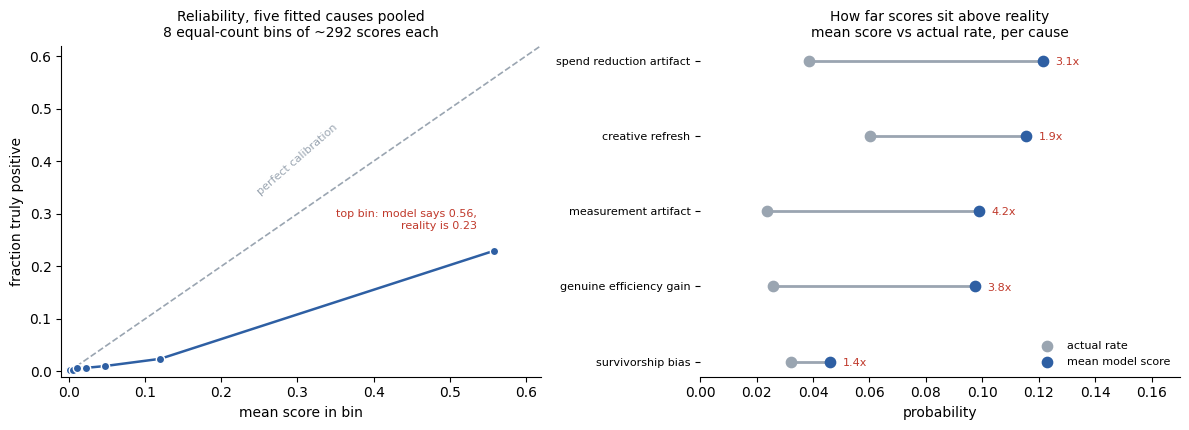

pooled: mean score 0.096 vs actual rate 0.036 = 2.7x inflated


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))

# ---- Left: reliability, all fitted causes pooled into equal-count bins. Pooling and quantile
# bins are both deliberate: per-cause fixed-width bins left survivorship_bias with 2 usable
# points, which draws a straight line and reads as a finding it is not.
ax = axes[0]
score = oof[L.FITTED_CAUSES].values.ravel()
truth = df[[f'y_{c}' for c in L.FITTED_CAUSES]].values.ravel()
edges = np.unique(np.quantile(score, np.linspace(0, 1, 9)))   # 8 bins of equal count
bin_idx = np.clip(np.digitize(score, edges[1:-1]), 0, len(edges) - 2)

xs, ys, ns = [], [], []
for b in range(len(edges) - 1):
    m = bin_idx == b
    if m.sum() >= 20:
        xs.append(score[m].mean()); ys.append(truth[m].mean()); ns.append(int(m.sum()))

LIM = 0.62   # scores never exceed this in any bin mean; full 0-1 axes would waste 40% of the panel
ax.plot([0, LIM], [0, LIM], '--', color=COLOR_MUTED, linewidth=1.2, zorder=1)
ax.plot(xs, ys, '-o', color=COLOR_PRIMARY, linewidth=1.8, markersize=6, zorder=3,
        markeredgecolor='white', markeredgewidth=1)
ax.annotate(f'top bin: model says {xs[-1]:.2f},\nreality is {ys[-1]:.2f}', (xs[-1], ys[-1]),
            textcoords='offset points', xytext=(-12, 16), fontsize=8, color=COLOR_FLAG, ha='right')
ax.text(0.30, 0.335, 'perfect calibration', fontsize=8, color=COLOR_MUTED, rotation=41, ha='center')
ax.set_xlim(-0.01, LIM); ax.set_ylim(-0.01, LIM)
ax.set_xlabel('mean score in bin'); ax.set_ylabel('fraction truly positive')
ax.set_title(f'Reliability, five fitted causes pooled\n8 equal-count bins of ~{ns[0]} scores each',
             fontsize=10)
ax.spines[['top', 'right']].set_visible(False)

# ---- Right: calibration in the large. No binning, so nothing here depends on bin choices.
ax = axes[1]
mean_score = [oof[c].mean() for c in L.FITTED_CAUSES]
actual_rate = [df[f'y_{c}'].mean() for c in L.FITTED_CAUSES]
order = np.argsort(mean_score)
rows = np.arange(len(L.FITTED_CAUSES))

for k, o in enumerate(order):
    ax.plot([actual_rate[o], mean_score[o]], [k, k], color=COLOR_MUTED, linewidth=2, zorder=1)
    ax.annotate(f'{mean_score[o] / actual_rate[o]:.1f}x', (mean_score[o], k),
                textcoords='offset points', xytext=(9, -3), fontsize=8, color=COLOR_FLAG)
ax.scatter([actual_rate[o] for o in order], rows, color=COLOR_MUTED, s=55, zorder=3,
           label='actual rate')
ax.scatter([mean_score[o] for o in order], rows, color=COLOR_PRIMARY, s=55, zorder=3,
           label='mean model score')
ax.set_yticks(rows)
ax.set_yticklabels([L.FITTED_CAUSES[o].replace('_', ' ') for o in order], fontsize=8)
ax.set_xlim(0, 0.17); ax.set_xlabel('probability')
ax.set_title('How far scores sit above reality\nmean score vs actual rate, per cause', fontsize=10)
ax.legend(fontsize=8, frameon=False, loc='lower right')
ax.spines[['top', 'right', 'left']].set_visible(False)

plt.tight_layout(); plt.show()

print(f'pooled: mean score {score.mean():.3f} vs actual rate {truth.mean():.3f} '
      f'= {score.mean() / truth.mean():.1f}x inflated')

**Left.** The pooled curve sits below the diagonal in every bin, so scores run consistently higher than the observed rate. In the top bin the model averages 0.56 against a true rate of 0.23.

**Right.** Every cause is inflated, from 1.4x on survivorship bias to 4.2x on measurement artifact, and 2.7x pooled. `class_weight='balanced'` is the reason: it tells the model to treat a 3% positive class as if it were 50%, which lifts the intercept. That buys recall on rare causes and destroys the absolute scale.

The practical consequence is a wording rule. Report "ranked highest for survivorship bias", never "70% chance of survivorship bias". The Brier score and log loss in the section 7 table put the same finding in one number.

## 8. Rank the feature evidence

All 60 features enter each fitted model. This notebook does not select the top features and refit. Ranking happens after classification and answers four questions, coarse to fine:

1. **Which signal family matters?** Grouped permutation importance shuffles one related feature block in held-out folds and measures the drop in PR-AUC.
2. **Which individual feature matters?** The same procedure, applied one column at a time.
3. **In which direction?** Standardized logistic coefficients show whether a larger value raises or lowers a cause score.
4. **Why did this one investigation score that way?** The local contribution $\beta_j x_j$, shown in section 9.

Block level runs first, because correlated lags of one signal split credit when permuted separately, which makes the block answer the more stable claim. The feature-level table then names the specific column and lag inside the winning block.

Importance here is explanatory, not causal. A high CTR ranking means the classifier uses CTR patterns to recognize the synthetic label, not that CTR caused the outcome.

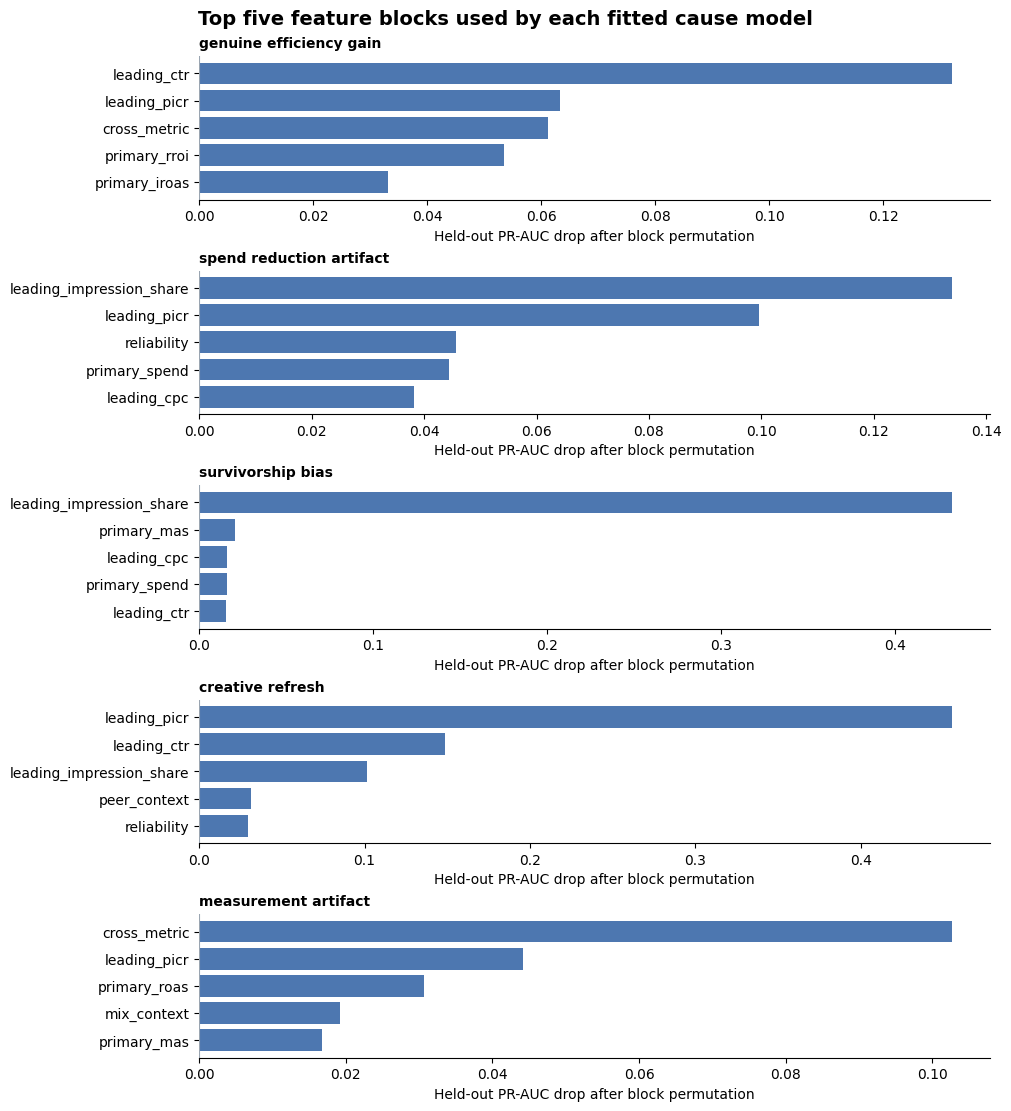

Top three held-out feature blocks per cause:
                   cause                    block  pr_auc_drop
        creative_refresh             leading_picr     0.455380
        creative_refresh              leading_ctr     0.148388
        creative_refresh leading_impression_share     0.101238
 genuine_efficiency_gain              leading_ctr     0.132116
 genuine_efficiency_gain             leading_picr     0.063263
 genuine_efficiency_gain             cross_metric     0.061271
    measurement_artifact             cross_metric     0.102729
    measurement_artifact             leading_picr     0.044234
    measurement_artifact             primary_roas     0.030646
spend_reduction_artifact leading_impression_share     0.133951
spend_reduction_artifact             leading_picr     0.099646
spend_reduction_artifact              reliability     0.045603
       survivorship_bias leading_impression_share     0.432820
       survivorship_bias              primary_mas     0.020730
       sur

In [16]:
def grouped_oof_permutation_importance(X, y_true, groups, blocks, n_repeats=5, seed=RNG_SEED):
    '''Measure block-level PR-AUC loss on event-grouped held-out folds.'''
    rng = np.random.default_rng(seed)
    fold_drops = {name: [] for name in blocks}
    fold_weights = {name: [] for name in blocks}
    cv = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=RNG_SEED)

    for train_idx, test_idx in cv.split(X, y_true, groups):
        y_test = y_true[test_idx]
        if y_test.sum() == 0:
            continue
        model = make_model().fit(X.iloc[train_idx], y_true[train_idx])
        X_test = X.iloc[test_idx]
        base = average_precision_score(y_test, model.predict_proba(X_test)[:, 1])

        for block, cols in blocks.items():
            drops = []
            for _ in range(n_repeats):
                permuted = X_test.copy()
                order = rng.permutation(len(permuted))
                permuted.loc[:, cols] = X_test[cols].iloc[order].to_numpy()
                score = model.predict_proba(permuted)[:, 1]
                drops.append(base - average_precision_score(y_test, score))
            fold_drops[block].append(np.mean(drops))
            fold_weights[block].append(y_test.sum())

    return {
        block: float(np.average(fold_drops[block], weights=fold_weights[block]))
        for block in blocks
    }

importance_rows = []
for c in L.FITTED_CAUSES:
    target = df[f'y_{c}'].values
    block_importance = grouped_oof_permutation_importance(
        X, target, groups, L.FEATURE_BLOCKS,
    )
    for block, value in block_importance.items():
        importance_rows.append({'cause': c, 'block': block, 'pr_auc_drop': value})

importance = pd.DataFrame(importance_rows)
top = (importance.sort_values('pr_auc_drop', ascending=False)
       .groupby('cause').head(3)
       .sort_values(['cause', 'pr_auc_drop'], ascending=[True, False]))

fig, axes = plt.subplots(len(L.FITTED_CAUSES), 1, figsize=(10, 11), constrained_layout=True)
for ax, cause in zip(axes, L.FITTED_CAUSES):
    view = (importance[importance.cause == cause]
            .nlargest(5, 'pr_auc_drop')
            .sort_values('pr_auc_drop'))
    ax.barh(view['block'], view['pr_auc_drop'], color=COLOR_PRIMARY, alpha=0.85)
    ax.axvline(0, color=COLOR_MUTED, linewidth=0.8)
    ax.set_title(cause.replace('_', ' '), loc='left', fontsize=10, fontweight='bold')
    ax.set_xlabel('Held-out PR-AUC drop after block permutation')
    ax.spines[['top', 'right', 'left']].set_visible(False)

fig.suptitle('Top five feature blocks used by each fitted cause model',
             fontsize=14, fontweight='bold')
plt.show()

print('Top three held-out feature blocks per cause:')
print(top.to_string(index=False))


Use the chart to compare signal families within a cause, not model quality across causes. A large positive bar means breaking the link between that block and the held-out labels cost PR-AUC. A bar near zero means the block added little unique ranking information. A negative bar means shuffling improved the fold result, which is a warning that the apparent relationship is unstable at this sample size.

Expected signatures give a reasonableness check: genuine efficiency should lean on CTR or PICR evidence, measurement artifacts on the ROAS-RROI wedge, spend reduction on spend or impression-share evidence. Agreement supports simulator recovery; disagreement triggers an ablation or a data-quality check.

### Which individual feature drives each cause

Block importance names the signal family. Repeating the permutation on single columns names the specific feature and lag each cause depends on. Runtime is about 25 seconds.

In [17]:
def feature_oof_permutation_importance(X, y_true, groups, features,
                                        n_repeats=5, seed=RNG_SEED):
    '''Held-out PR-AUC loss when one feature column is shuffled on its own.'''
    rng = np.random.default_rng(seed)
    drops = {f: [] for f in features}
    weights = {f: [] for f in features}
    cv = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=RNG_SEED)

    for train_idx, test_idx in cv.split(X, y_true, groups):
        y_test = y_true[test_idx]
        if y_test.sum() == 0:
            continue
        model = make_model().fit(X.iloc[train_idx], y_true[train_idx])
        X_test = X.iloc[test_idx]
        base = average_precision_score(y_test, model.predict_proba(X_test)[:, 1])
        for f in features:
            fold = []
            for _ in range(n_repeats):
                permuted = X_test.copy()
                permuted[f] = X_test[f].iloc[rng.permutation(len(permuted))].to_numpy()
                fold.append(base - average_precision_score(
                    y_test, model.predict_proba(permuted)[:, 1]))
            drops[f].append(np.mean(fold))
            weights[f].append(y_test.sum())

    return {f: float(np.average(drops[f], weights=weights[f])) for f in features}

block_of = {f: b for b, fs in L.FEATURE_BLOCKS.items() for f in fs}
coef_lookup = {c: dict(zip(L.FEATURES, fitted_models[c].named_steps['lr'].coef_[0]))
               for c in L.FITTED_CAUSES}

feature_rows = []
for c in L.FITTED_CAUSES:
    scores = feature_oof_permutation_importance(X, df[f'y_{c}'].values, groups, L.FEATURES)
    for f, drop in scores.items():
        feature_rows.append({
            'cause': c, 'feature': f, 'block': block_of[f],
            'pr_auc_drop': drop, 'std_coef': coef_lookup[c][f],
        })

feature_importance = pd.DataFrame(feature_rows)
feature_importance['direction'] = np.where(
    feature_importance['std_coef'] > 0, 'higher raises score', 'higher lowers score')

for c in L.FITTED_CAUSES:
    print(f'\n{c}')
    top5 = (feature_importance[feature_importance.cause == c]
            .nlargest(5, 'pr_auc_drop')[['feature', 'block', 'pr_auc_drop',
                                         'std_coef', 'direction']])
    print(top5.round(4).to_string(index=False))


genuine_efficiency_gain
            feature        block  pr_auc_drop  std_coef           direction
    wedge_roas_rroi cross_metric       0.0623   -0.4963 higher lowers score
n_metrics_triggered cross_metric       0.0599   -0.8387 higher lowers score
         rroi_resid primary_rroi       0.0555    0.4158 higher raises score
  target_minus_peer peer_context       0.0409    0.2345 higher raises score
        spend_share  mix_context       0.0344   -0.5325 higher lowers score

spend_reduction_artifact
            feature                    block  pr_auc_drop  std_coef           direction
impression_share_d3 leading_impression_share       0.0755   -0.6022 higher lowers score
     ctr_resid_lag1              leading_ctr       0.0563    0.3256 higher raises score
            picr_d3             leading_picr       0.0535    0.4533 higher raises score
    picr_resid_lag1             leading_picr       0.0490    0.1657 higher raises score
    conc_iroas_rroi             cross_metric       0.

Each cause depends on a handful of columns, and the lag matters. `creative_refresh` leans on `picr_resid_lag2`, the PICR residual two months back rather than the current month: what identifies a refresh is the ramp behind it. `survivorship_bias` leans on the current `impression_share_resid`, and `measurement_artifact` on `wedge_roas_rroi`, exactly the ROAS-RROI divergence that defines it.

### Cause-by-signal summary

One row per cause: the winning block, the winning feature, its direction, and whether that matches the mechanism the generator injected. If you read one thing in this section, read this table.

In [18]:
EXPECTED = {   # from the mechanism table in data/data_dictionary.md
    'genuine_efficiency_gain': 'CTR and PICR up, spend and impression share stable',
    'spend_reduction_artifact': 'impression share down, MAS flat or down',
    'survivorship_bias': 'sharp impression-share cut',
    'creative_refresh': 'CTR and PICR up with a recent ramp',
    'measurement_artifact': 'ROAS moves, RROI does not',
}

summary_rows = []
for c in L.FITTED_CAUSES:
    blk = importance[importance.cause == c].nlargest(1, 'pr_auc_drop').iloc[0]
    ftr = feature_importance[feature_importance.cause == c].nlargest(1, 'pr_auc_drop').iloc[0]
    lag = ('t-2' if ftr['feature'].endswith('lag2')
           else 't-2..t' if ftr['feature'].endswith('_d3')
           else 't-1' if ftr['feature'].endswith('lag1')
           else 't-1..t' if ftr['feature'].endswith('_d1')
           else 't')
    summary_rows.append({
        'cause': c,
        'top_block': blk['block'],
        'block_drop': round(blk['pr_auc_drop'], 3),
        'top_feature': ftr['feature'],
        'feature_drop': round(ftr['pr_auc_drop'], 3),
        'lag': lag,
        'direction': ftr['direction'],
        'expected_signature': EXPECTED[c],
    })

cause_signal_summary = pd.DataFrame(summary_rows).set_index('cause')
print(cause_signal_summary[['top_block', 'block_drop', 'top_feature',
                            'feature_drop', 'lag', 'direction']].to_string())
print()
for c, r in cause_signal_summary.iterrows():
    print(f"{c}\n  learned  : {r['top_feature']} at {r['lag']}, {r['direction']}")
    print(f"  expected : {r['expected_signature']}")

                                         top_block  block_drop             top_feature  feature_drop     lag            direction
cause                                                                                                                            
genuine_efficiency_gain                leading_ctr       0.132         wedge_roas_rroi         0.062       t  higher lowers score
spend_reduction_artifact  leading_impression_share       0.134     impression_share_d3         0.075  t-2..t  higher lowers score
survivorship_bias         leading_impression_share       0.433  impression_share_resid         0.120       t  higher lowers score
creative_refresh                      leading_picr       0.455         picr_resid_lag2         0.257     t-2  higher raises score
measurement_artifact                  cross_metric       0.103         wedge_roas_rroi         0.112       t  higher raises score

genuine_efficiency_gain
  learned  : wedge_roas_rroi at t, higher lowers score
  expected

Every fitted cause lands on the signal block its injected mechanism implies, which is the check that matters. `survivorship_bias` and `spend_reduction_artifact` both land on impression share at different lags, the aggregate-level signature of two causes the data dictionary describes as near-identical by construction.

`genuine_efficiency_gain` is the one to read carefully. Its top feature is `wedge_roas_rroi` with a negative sign rather than a CTR or PICR term, so the model is partly learning what the cause is **not** (no reporting wedge) rather than what it is. That is what 12 positive rows buy.

## 9. Analyst output

Every investigation renders to one card. `attribution_lib.narrate` fills this template:

> **{BU} / {brand} / {channel} / {month}**: the observed pattern is most consistent with **{top cause} ({score})** under the synthetic training distribution. Largest contributing signals: {top 3 signals with signed contributions}. Second candidate: {runner-up} ({score}). This is diagnostic evidence, not proof of cause.

When no cause clears the threshold, the card switches to the abstention form:

> **{BU} / {brand} / {channel} / {month}**: insufficient evidence for a known cause (top score {cause} {score}, below the {threshold} abstention threshold). Route to manual review.

The hedged wording is deliberate. The analyst receives ranked evidence and the signals behind it, never a verdict.

In [19]:
def contributions(cause, i):
    """Per-case beta_j * x_j, the local explanation for a linear model."""
    pipe = fitted_models[cause]
    xs = pipe.named_steps['scale'].transform(
        pipe.named_steps['impute'].transform(X.iloc[[i]]))[0]
    return pd.Series(xs * pipe.named_steps['lr'].coef_[0], index=L.FEATURES)

examples = [int(oof[L.FITTED_CAUSES].max(axis=1).idxmax()),          # most confident
            int(oof[L.CAUSES].max(axis=1).idxmin())]                 # least confident
for i in examples:
    s = oof.loc[i, L.CAUSES]
    top_cause = s.idxmax()
    ctr = contributions(top_cause, i) if top_cause in L.FITTED_CAUSES else pd.Series(dtype=float)
    print(L.narrate(df.loc[i], s, ctr, abstain_below=ABSTAIN))
    truth = df.loc[i, 'cause_types'] or '(no injected cause)'
    print(f'   ground truth: {truth}\n')

Snacks / CrispBite / display / 2023-01: the observed pattern is most consistent with survivorship bias (1.00) under the synthetic training distribution. Largest contributing signals: impression_share_resid (+5.55), impression_share_d1 (+3.23), impression_share_d3 (+1.57). Second candidate: spend reduction artifact (1.00). This is diagnostic evidence, not proof of cause.
   ground truth: creative_refresh|spend_reduction_artifact|survivorship_bias

HomeCare / CleanWave / paid_search / 2023-11: insufficient evidence for a known cause (top score measurement artifact 0.03, below the 0.30 abstention threshold). Route to manual review.
   ground truth: (no injected cause)



The confident case names a cause and the signals supporting it. The weak case abstains instead of returning the least-bad label. Abstention is the property that keeps a wrong narrative away from a stakeholder.

## 10. Exports

In [20]:
comparison.round(4).to_csv('model_comparison.csv', index=False)
importance.round(5).to_csv('feature_importance.csv', index=False)
feature_importance.round(5).to_csv('feature_importance_by_feature.csv', index=False)
cause_signal_summary.to_csv('cause_signal_summary.csv')

preds = df[L.KEY].copy()
preds['n_metrics_triggered'] = df['n_metrics_triggered']
preds['true_causes'] = df['cause_types']
preds['event_group'] = df['event_group']
for c in L.CAUSES:
    preds[f'y_{c}'] = df[f'y_{c}']
    preds[f'score_{c}'] = oof[c].round(4)
    preds[f'scorer_{c}'] = 'logistic_l2' if c in L.FITTED_CAUSES else 'expert_rule'
preds['top_cause'] = oof[L.CAUSES].idxmax(axis=1)
preds['top_score'] = oof[L.CAUSES].max(axis=1).round(4)
preds['state'] = np.where(preds['top_score'] < ABSTAIN, 'insufficient_evidence', 'cause_proposed')
preds.to_csv('attribution_predictions.csv', index=False)

for f, n in [('model_comparison.csv', len(comparison)),
             ('feature_importance.csv', len(importance)),
             ('feature_importance_by_feature.csv', len(feature_importance)),
             ('cause_signal_summary.csv', len(cause_signal_summary)),
             ('attribution_predictions.csv', len(preds))]:
    print(f'wrote {f}: {n} rows')

assert preds[[f'score_{c}' for c in L.CAUSES]].values.min() >= 0
assert preds[[f'score_{c}' for c in L.CAUSES]].values.max() <= 1
print('\nscore range check: PASS (all scores in [0,1], no sum-to-one constraint imposed)')
print(preds['state'].value_counts().to_string())

wrote model_comparison.csv: 21 rows
wrote feature_importance.csv: 65 rows
wrote feature_importance_by_feature.csv: 300 rows
wrote cause_signal_summary.csv: 5 rows
wrote attribution_predictions.csv: 466 rows

score range check: PASS (all scores in [0,1], no sum-to-one constraint imposed)
state
insufficient_evidence    261
cause_proposed           205


## 11. Causal honesty and limits

Two claims in this section are usually just asserted. Both are measurable on this panel, so both get measured before they are stated.

In [21]:
# Proof 1: the selection boundary. Attribution can only explain what Task 1 hands it.
gt_all = pd.read_csv('../data/ground_truth/ground_truth.csv', parse_dates=['month'])
candidate_keys = set(map(tuple, df[L.KEY].values))
anomaly_rows = gt_all[gt_all['is_anomaly']]
reaching = sum(1 for r in anomaly_rows[L.KEY].values if tuple(r) in candidate_keys)
events_reaching = {e for ids in df.loc[df['any_cause'] == 1, 'event_ids']
                   for e in ids.split('|') if e}

print(f'True anomaly rows in the panel : {len(anomaly_rows)}')
print(f'  reaching Task 2 as candidates: {reaching} ({reaching/len(anomaly_rows):.0%})')
print(f'  invisible to attribution     : {len(anomaly_rows)-reaching} '
      f'({1-reaching/len(anomaly_rows):.0%})')
print(f'Events with at least one row reaching Task 2: {len(events_reaching)} of {len(ev)}')

# Event arrival rate. This is the constraint that decides retraining cadence in production:
# adjudicated labels accumulate far too slowly to drive a retrain.
months = bm['month'].nunique()
per_year = 12 * len(ev) / months
print(f'\n{len(ev)} events over {months} months = {per_year:.1f} events/year')
print(f'  months to accumulate 100 adjudicated events: {100/(len(ev)/months):.0f} '
      f'(~{100/(len(ev)/months)/12:.0f} years)')

True anomaly rows in the panel : 254
  reaching Task 2 as candidates: 106 (42%)
  invisible to attribution     : 148 (58%)
Events with at least one row reaching Task 2: 25 of 37

37 events over 48 months = 9.2 events/year
  months to accumulate 100 adjudicated events: 130 (~11 years)


Attribution never sees 58% of the real anomaly rows, and 12 of 37 events are invisible to it entirely. Every score here is conditional on the Task 1 threshold, so a cause the detector misses cannot be explained by this system, only left unreported.

In [22]:
# Proof 2: are the causes actually separable? Row = what was truly injected,
# column = mean score the model for that column gave those same rows.
confusion_rows = []
for true_cause in L.FITTED_CAUSES:
    mask = df[f'y_{true_cause}'] == 1
    confusion_rows.append({'true_cause': true_cause, 'n': int(mask.sum()),
                           **{sc: round(float(oof.loc[mask, sc].mean()), 3)
                              for sc in L.FITTED_CAUSES}})
cross_cause = pd.DataFrame(confusion_rows).set_index('true_cause')
print(cross_cause.to_string())

wins = [c for c in L.FITTED_CAUSES if cross_cause.loc[c, L.FITTED_CAUSES].idxmax() == c]
print(f'\nCauses whose own model is the top scorer on their own positive rows: '
      f'{len(wins)} of {len(L.FITTED_CAUSES)}  {wins}')

                           n  genuine_efficiency_gain  spend_reduction_artifact  survivorship_bias  creative_refresh  measurement_artifact
true_cause                                                                                                                                
genuine_efficiency_gain   12                    0.465                     0.504              0.219             0.499                 0.166
spend_reduction_artifact  18                    0.393                     0.420              0.311             0.467                 0.333
survivorship_bias         15                    0.376                     0.813              0.799             0.561                 0.278
creative_refresh          28                    0.430                     0.578              0.319             0.881                 0.314
measurement_artifact      11                    0.206                     0.480              0.311             0.447                 0.296

Causes whose own model is 

Only `creative_refresh` is the top scorer on its own positive rows. `survivorship_bias` loses to `spend_reduction_artifact`, 0.813 against 0.799, which is the near-identity the data dictionary describes showing up in measured output. `measurement_artifact` ranks fourth of five on its own rows.

Per-cause PR-AUC looks respectable in isolation. This table shows how much of that is a shared "something anomalous happened" signal rather than cause-specific evidence, and it is the strongest single reason to present ranked candidates instead of one answer.

### What is causal and what is not

These scores estimate $P(\text{injected cause label}\mid\text{observed evidence},\ \text{Task 1 flagged})$. They do not estimate the causal effect of CTR, spend or creative on performance, and nothing in this pipeline could: nothing was randomized or withheld, so the counterfactual is never observed. Synthetic causes are causal inside the simulator only. Using iROAS, itself an incrementality estimate, as one feature does not make the classifier causal.

### Where more data helps, and where it cannot

More rows reduce variance. Only more columns fix identification.

| cause | limited by | more panels help? |
|---|---|---|
| `mix_shift_artifact`, `external_demand_spike` | one event each | yes, distinct mechanisms with no data behind them |
| `measurement_artifact` | 11 positives | yes, the ROAS-RROI wedge is a distinct signature |
| `survivorship_bias` vs `spend_reduction_artifact` | identification | **no**, near-identical by construction; needs placement-level retention data |
| `genuine_efficiency_gain` vs `creative_refresh` | both | partly; full separation needs creative launch dates |

`proposal_attribution.md` carries the production treatment and the full limits.

### Future work

- **Boosted-tree challenger.** A shallow, regularized XGBoost per cause on the same folds and features. Scoped out here because 23 labeled event groups cannot support a fair family selection: the extra capacity would go into memorizing events rather than mechanisms. Worth running once auxiliary panels exist.
- **Unweighted models.** `class_weight='balanced'` buys recall on rare causes and is the direct cause of the score inflation in the reliability plot. An unweighted refit would trade that recall back for usable probabilities.
- **Auxiliary training panels.** 8 to 10 seed-parameterized panels would supply the independent events needed to fit the two rule-scored causes, support Platt calibration, and justify evaluation slices and bootstrap intervals.